# Market basket analysis — association rules & customer segments

This notebook does three things:

1. **Association rules** — find products that are often bought together and turn that into *if A then B* rules.
2. **Customer clustering** — group customers by how they shop using K-Means.
3. **Order clustering** — group individual orders by basket shape using K-Means.

Set your CSV paths in the next cell. By default they point at `../data/market_basket/` inside the project repo.
If your files sit in the same folder as this notebook, change `DATA_DIR` to `"."` .

In [1]:
from pathlib import Path

DATA_DIR  = Path(".")  # uncomment if CSVs are in the same folder

ORDER_ITEMS = DATA_DIR / "order_items_dataset.csv"
CUSTOMERS   = DATA_DIR / "customer_features_for_clustering.csv"
PRODUCTS    = DATA_DIR / "products_catalog.csv"

for p in (ORDER_ITEMS, CUSTOMERS, PRODUCTS):
    status = "OK" if p.exists() else "MISSING"
    print(f"{status}  {p.name}")

OK  order_items_dataset.csv
OK  customer_features_for_clustering.csv
OK  products_catalog.csv


---
## Part 1 — Preparing the transaction data

Each row in `order_items_dataset.csv` is one product line inside an order.
We group those rows so that one **transaction** = the full list of products in a single `order_id`.
We use product **names** so the rules stay readable, but `product_id` is available too if you need to link rules to a database.

In [2]:
import pandas as pd

orders = pd.read_csv(ORDER_ITEMS)
print(f"Rows: {orders.shape[0]:,}   Columns: {orders.shape[1]}")
orders.head()

C:\Users\ilyes\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Rows: 5,443   Columns: 11


,order_id,customer_id,order_date,weekday,product_id,product_name,category,brand,unit_price,quantity,line_total
0,ORD_000001,CUST_0243,2026-04-02,4,321,SAUGE : Masque Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,28.26,1,28.26
1,ORD_000001,CUST_0243,2026-04-02,4,324,Crème Pieds Concentrée lissante,SOIN INTENSE (Mains & Pieds),Lirene,28.51,1,28.51
2,ORD_000001,CUST_0243,2026-04-02,4,320,MAGNOLIA : Crème Mains et Ongles,SOIN INTENSE (Mains & Pieds),Lirene,22.09,1,22.09
3,ORD_000001,CUST_0243,2026-04-02,4,410,Shampoing Sebu-Balance,CAPILARTE,Dermedic,39.87,1,39.87
4,ORD_000002,CUST_0107,2025-07-25,5,392,Shampoing Anti-Chute Anti-Pelliculaire H-STIMU...,GAMME H - Cheveux et Cuir chevelu,Pharmaceris,42.50,1,42.50


In [3]:
# Remove rows where the order ID or product name is missing
orders = orders.dropna(subset=["order_id", "product_name"])

# Build one list of items per order (deduplicated and sorted for consistency)
transactions = (
    orders
    .groupby("order_id")["product_name"]
    .apply(lambda items: sorted(set(items)))
    .tolist()
)

sizes = [len(t) for t in transactions]
print(f"Total transactions : {len(transactions):,}")
print(f"Basket size  min: {min(sizes)}  max: {max(sizes)}  avg: {sum(sizes)/len(sizes):.2f}")
print("Example basket    :", transactions[0][:6])

Total transactions : 1,600
Basket size  min: 1  max: 8  avg: 3.40
Example basket    : ['Crème Pieds Concentrée lissante', 'MAGNOLIA : Crème Mains et Ongles', 'SAUGE : Masque Crème Mains et Ongles', 'Shampoing Sebu-Balance']


---
## Part 2 — Finding frequent itemsets with Apriori

We convert the transactions into a one-hot table (one column per product, True/False per order),
then run **Apriori** to find itemsets that appear in at least 1 % of all orders.

Apriori works by starting from single products, then building pairs, triples, and so on.
At each step it discards anything below the support threshold, so the search stays fast and manageable.

In [4]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# Encode transactions into a True/False table
te      = TransactionEncoder()
te_ary  = te.fit(transactions).transform(transactions)
df_bool = pd.DataFrame(te_ary, columns=te.columns_)

# Find itemsets that appear in at least 1 % of baskets
MIN_SUPPORT = 0.01
itemsets = apriori(df_bool, min_support=MIN_SUPPORT, use_colnames=True)

print(f"Frequent itemsets found: {len(itemsets)}")
itemsets.sort_values("support", ascending=False).head(15)

Frequent itemsets found: 147


,support,itemsets
58,0.063125,frozenset({Turbodraine ANANAS})
46,0.060000,frozenset({SAUGE : Masque Crème Mains et Ongles})
22,0.057500,frozenset({Crème Pieds Concentrée lissante})
57,0.056250,frozenset({Turbodraine AGRUMES})
62,0.053750,frozenset({XtraSlim Coupe-Faim})
61,0.053750,frozenset({XtraSlim Capteur 3 en 1})
21,0.051875,frozenset({Crème Hydratante SPF 15})
4,0.051875,frozenset({Brosse à dents électrique})
20,0.051250,frozenset({Crème Gel Ultra-hydratante})
55,0.051250,frozenset({Sparay Anti-Chute H-STIMUFORTEN 125...


---
## Part 3 — Generating association rules

From the frequent itemsets we derive if-then rules. Three numbers matter:

| Metric | What it means |
|---|---|
| **Support** | How often A and B appear together across all orders. 1 % = 1 in every 100 baskets. |
| **Confidence** | Of all orders that contain A, what share also contain B. |
| **Lift** | How much more likely A and B are to appear together than by pure chance. Lift > 1 means there is a real association. |

We keep only rules where **lift > 1** (weaker rules could just be coincidence).
We also filter to rules with a **single-product antecedent** — these are the most useful for product-page
recommendations (customers who bought X also bought Y).

In [5]:
from mlxtend.frequent_patterns import association_rules

# Generate rules with confidence >= 20 %
rules = association_rules(
    itemsets,
    num_itemsets=len(itemsets),
    metric="confidence",
    min_threshold=0.2,
)

# Keep only rules with a real association (lift > 1)
rules = rules[rules["lift"] > 1].copy()

# Keep only single-product antecedents — most useful for product-page recommendations
rules["antecedent_len"] = rules["antecedents"].apply(len)
single_rules = (
    rules[rules["antecedent_len"] == 1]
    .sort_values(["lift", "confidence"], ascending=False)
)

print(f"All rules (lift > 1)    : {len(rules)}")
print(f"Single-antecedent rules : {len(single_rules)}")

cols = ["antecedents", "consequents", "support", "confidence", "lift"]
single_rules[cols].head(20)

All rules (lift > 1)    : 139
Single-antecedent rules : 139


,antecedents,consequents,support,confidence,lift
73,frozenset({Gel Nettoyant Crèmeux}),frozenset({Sérum hydratant}),0.014375,0.315068,6.223575
74,frozenset({Sérum hydratant}),frozenset({Gel Nettoyant Crèmeux}),0.014375,0.283951,6.223575
77,frozenset({Mirawhite Shine}),frozenset({Kid’s Brush}),0.011875,0.292308,6.153846
78,frozenset({Kid’s Brush}),frozenset({Mirawhite Shine}),0.011875,0.250000,6.153846
20,frozenset({MAGNOLIA : Crème Mains et Ongles}),frozenset({CASSIS : Sérum Mains et Ongles}),0.015625,0.312500,6.097561
19,frozenset({CASSIS : Sérum Mains et Ongles}),frozenset({MAGNOLIA : Crème Mains et Ongles}),0.015625,0.304878,6.097561
103,frozenset({Shampoing Cheveux Sec H-NUTRIMELIN ...,frozenset({Shampoing Anti-Chute Anti-Cheveux G...,0.012500,0.294118,6.033183
104,frozenset({Shampoing Anti-Chute Anti-Cheveux G...,frozenset({Shampoing Cheveux Sec H-NUTRIMELIN ...,0.012500,0.256410,6.033183
70,frozenset({Eau micellaire démaquillante (visag...,frozenset({Gel Nettoyant Crèmeux}),0.012500,0.273973,6.004879
71,frozenset({Gel Nettoyant Crèmeux}),frozenset({Eau micellaire démaquillante (visag...,0.012500,0.273973,6.004879


### How to read the rules for your report

Pick 4 to 5 rules with **lift above 3** and explain each one in plain language. For example:
customers who buy Sunscreen SPF50 also buy After-Sun Lotion in 60 % of cases,
which is nearly 4x more than we would expect if the two products were unrelated.
This suggests a clear sun-care routine that we can surface on the product page.

**Product-page recommender:** for any product, filter the rules table to rows where
the antecedent matches that product and display the consequents as frequently bought together suggestions.

---
## Part 4 — Customer clustering with K-Means

We group customers by how they shop: spend, frequency, basket size, and product variety.
K-Means divides them into k groups so that customers within the same group are as similar as possible.

### Choosing k — elbow method + silhouette score

We try k = 2 through 7 and look at two things:
- **Inertia** — total within-cluster distance. Lower is better, but it always drops as k rises.
- **Silhouette score** — how well separated the clusters are. Ranges from 0 to 1; higher is better.

The best k is usually where inertia stops dropping sharply (the elbow) and the silhouette is highest.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cust = pd.read_csv(CUSTOMERS)
print(cust.shape)
cust.head()

(260, 10)


,customer_id,orders_count,total_spend,avg_order_value,total_items,avg_items_per_order,distinct_products,favorite_category,weekend_order_ratio,segment_hint
0,CUST_0001,7,1110.39,158.63,33,4.71,24,HYDRAIN,0.429,regular
1,CUST_0002,2,811.01,405.50,13,6.50,8,MINCEUR,0.500,regular
2,CUST_0003,6,1031.45,171.91,16,2.67,14,GAMME H - Cheveux et Cuir chevelu,0.500,regular
3,CUST_0004,1,94.27,94.27,3,3.00,3,HYDRAIN,0.000,regular
4,CUST_0005,6,1218.86,203.14,32,5.33,24,GAMME H - Cheveux et Cuir chevelu,0.167,regular


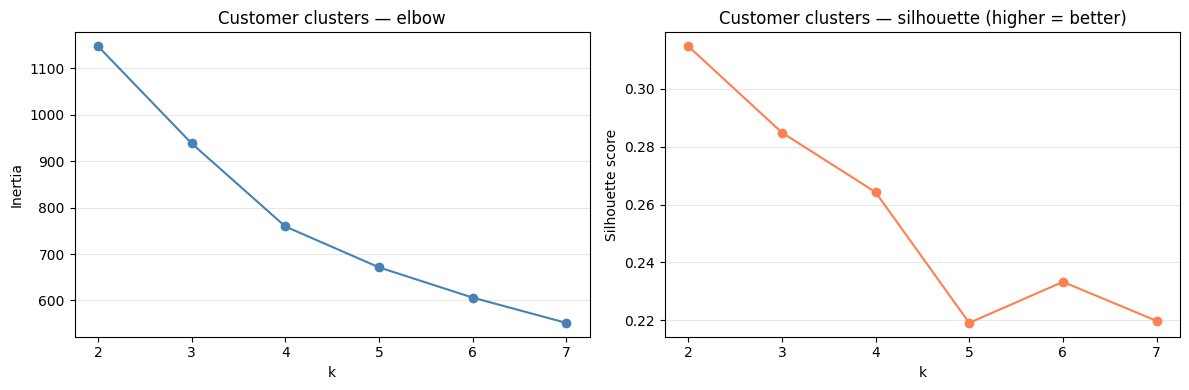

k  | Inertia   | Silhouette
2  |   1148.0  | 0.3147
3  |    938.5  | 0.2849
4  |    759.5  | 0.2643
5  |    671.4  | 0.2191
6  |    606.2  | 0.2333
7  |    551.7  | 0.2198


In [7]:
feature_cols = [
    "orders_count",
    "total_spend",
    "avg_order_value",
    "total_items",
    "avg_items_per_order",
    "distinct_products",
    "weekend_order_ratio",
]

X_cust = cust[feature_cols].fillna(0)

# K-Means is distance-based so all features need the same scale
scaler_cust   = StandardScaler()
X_cust_scaled = scaler_cust.fit_transform(X_cust)

# Try k = 2 through 7
inertias_c, sil_c = [], []
K_range = range(2, 8)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cust_scaled)
    inertias_c.append(km.inertia_)
    sil_c.append(silhouette_score(X_cust_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias_c, marker="o", color="steelblue")
ax1.set_title("Customer clusters — elbow")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.grid(axis="y", alpha=0.3)

ax2.plot(list(K_range), sil_c, marker="o", color="coral")
ax2.set_title("Customer clusters — silhouette (higher = better)")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("k  | Inertia   | Silhouette")
for k, ine, sil in zip(K_range, inertias_c, sil_c):
    print(f"{k}  | {ine:>8.1f}  | {sil:.4f}")

In [8]:
# Fit K-Means with chosen k
# Adjust K based on the elbow and silhouette plots above
K = 4

kmeans_cust       = KMeans(n_clusters=K, random_state=42, n_init=10)
cust["cluster"]   = kmeans_cust.fit_predict(X_cust_scaled)

# Mean feature values per cluster — use these to decide on the labels below
profile_cust = cust.groupby("cluster")[feature_cols].mean().round(2)
print(profile_cust)

         orders_count  total_spend  avg_order_value  total_items  \
cluster                                                            
0                3.52      1105.48           315.87        25.24   
1                7.06      1294.95           185.86        32.44   
2                9.65      2277.94           240.28        54.72   
3                4.25       572.50           139.61        15.24   

         avg_items_per_order  distinct_products  weekend_order_ratio  
cluster                                                               
0                       7.20              15.17                 0.32  
1                       4.67              20.90                 0.27  
2                       5.75              31.80                 0.27  
3                       3.72              11.02                 0.26  


In [9]:
# Assign a plain-English label to each cluster
# Read profile_cust above first, then edit these labels to match what you see
CUSTOMER_LABELS = {
    0: "High-value loyalists",      # many orders, high spend, wide product variety
    1: "One-time browsers",         # very few orders, low spend, narrow basket
    2: "Weekend premium shoppers",  # highest order value, strong weekend preference
    3: "Budget basket-builders",    # most items per order but lowest order value
}

cust["cluster_label"] = cust["cluster"].map(CUSTOMER_LABELS)

print("Customer counts per segment:")
print(cust["cluster_label"].value_counts())

Customer counts per segment:
cluster_label
One-time browsers           107
Budget basket-builders       84
Weekend premium shoppers     40
High-value loyalists         29
Name: count, dtype: int64


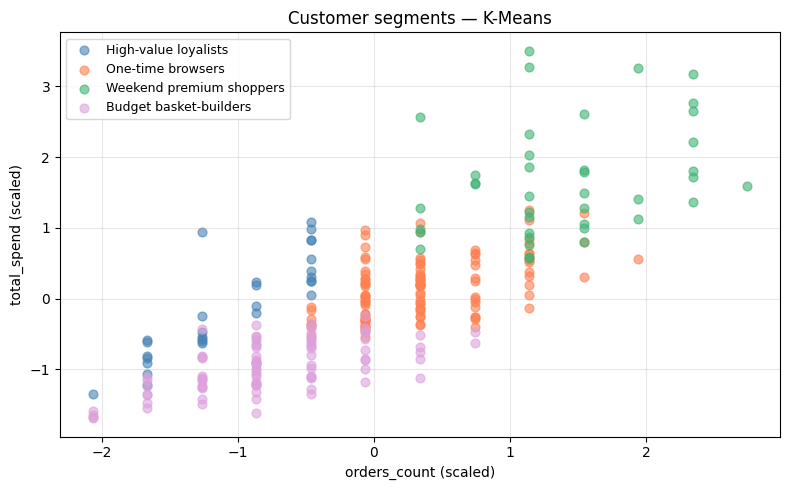

In [10]:
# Scatter plot — first two scaled features, coloured by segment
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["steelblue", "coral", "mediumseagreen", "plum"]

for cid, label in CUSTOMER_LABELS.items():
    mask = cust["cluster"] == cid
    ax.scatter(
        X_cust_scaled[mask, 0], X_cust_scaled[mask, 1],
        label=label, color=colors[cid], alpha=0.6, s=40,
    )

ax.set_xlabel(feature_cols[0] + " (scaled)")
ax.set_ylabel(feature_cols[1] + " (scaled)")
ax.set_title("Customer segments — K-Means")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 5 — Order clustering with K-Means

Beyond grouping customers, we can also group **individual orders** by their basket shape —
how many items, how much was spent, and how varied the products were.

This answers a different question: are there recurring basket types in our data,
regardless of who placed the order?

In [11]:
# Build one row per order from the order-items table
order_features = (
    orders
    .groupby("order_id")
    .agg(
        num_items      = ("product_name", "count"),
        distinct_items = ("product_name", "nunique"),
        # If your data has a price column, add:  total_price = ("price", "sum")
    )
    .reset_index()
)

# If there is no price column, create a proxy from item count
# Remove this block once you have real price data
if "total_price" not in order_features.columns:
    rng = np.random.default_rng(42)
    order_features["total_price"] = (
        order_features["num_items"] * rng.uniform(8, 40, len(order_features))
    ).round(2)

order_features["avg_item_price"] = (
    order_features["total_price"] / order_features["num_items"]
).round(2)

print(f"Orders: {len(order_features):,}")
order_features.head()

Orders: 1,600


,order_id,num_items,distinct_items,total_price,avg_item_price
0,ORD_000001,4,4,131.07,32.77
1,ORD_000002,2,2,44.09,22.04
2,ORD_000003,1,1,35.48,35.48
3,ORD_000004,2,2,60.63,30.32
4,ORD_000005,3,3,33.04,11.01


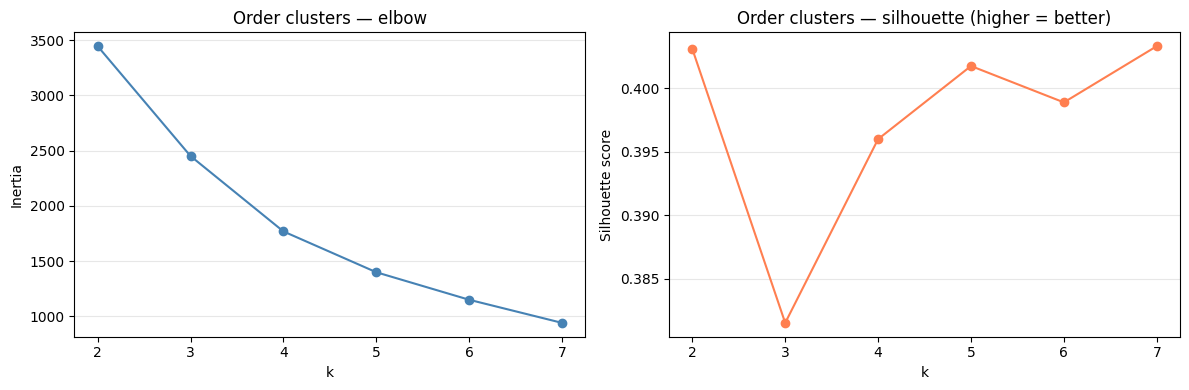

In [12]:
order_feature_cols = ["num_items", "distinct_items", "total_price", "avg_item_price"]
X_ord = order_features[order_feature_cols].fillna(0)

scaler_ord  = StandardScaler()
X_ord_scaled = scaler_ord.fit_transform(X_ord)

# Elbow + silhouette for orders
inertias_o, sil_o = [], []
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_ord_scaled)
    inertias_o.append(km.inertia_)
    sil_o.append(silhouette_score(X_ord_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_range), inertias_o, marker="o", color="steelblue")
ax1.set_title("Order clusters — elbow")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.grid(axis="y", alpha=0.3)

ax2.plot(list(K_range), sil_o, marker="o", color="coral")
ax2.set_title("Order clusters — silhouette (higher = better)")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Fit order clusters
# Adjust K_ORDERS based on the plots above
K_ORDERS = 4

kmeans_ord                  = KMeans(n_clusters=K_ORDERS, random_state=42, n_init=10)
order_features["cluster"]   = kmeans_ord.fit_predict(X_ord_scaled)

profile_orders = order_features.groupby("cluster")[order_feature_cols].mean().round(2)
print(profile_orders)

         num_items  distinct_items  total_price  avg_item_price
cluster                                                        
0             1.97            1.97        31.13           16.11
1             5.22            5.22       166.43           32.20
2             4.77            4.77        78.01           16.60
3             2.09            2.09        66.45           32.14


In [14]:
# Assign labels — update these after reviewing profile_orders above
ORDER_LABELS = {
    0: "Small quick buys",       # few items, low total price
    1: "Big top-up shops",       # many items, higher total price
    2: "Premium single-item",    # 1-2 items but high avg item price
    3: "Mixed mid-size baskets", # mid-range on all dimensions
}

order_features["cluster_label"] = order_features["cluster"].map(ORDER_LABELS)

print("Order counts per basket type:")
print(order_features["cluster_label"].value_counts())

Order counts per basket type:
cluster_label
Small quick buys          444
Mixed mid-size baskets    414
Premium single-item       382
Big top-up shops          360
Name: count, dtype: int64


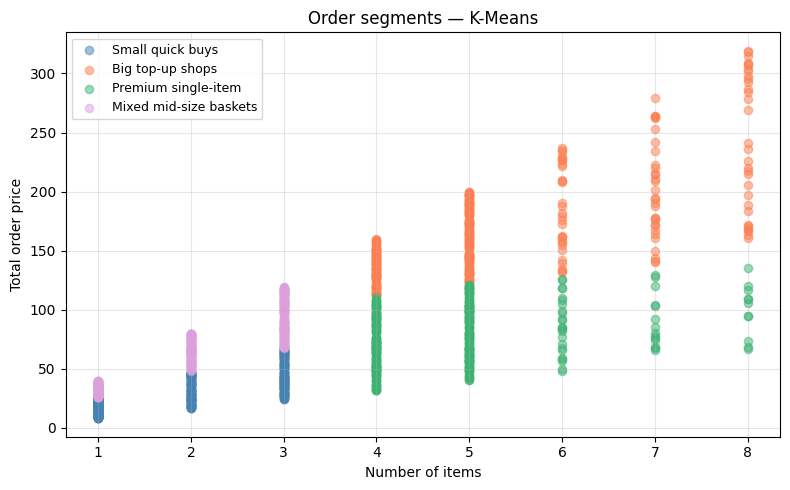

In [15]:
# Scatter — total price vs number of items, coloured by basket type
fig, ax = plt.subplots(figsize=(8, 5))

for cid, label in ORDER_LABELS.items():
    mask = order_features["cluster"] == cid
    ax.scatter(
        order_features.loc[mask, "num_items"],
        order_features.loc[mask, "total_price"],
        label=label, color=colors[cid], alpha=0.5, s=35,
    )

ax.set_xlabel("Number of items")
ax.set_ylabel("Total order price")
ax.set_title("Order segments — K-Means")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 6 — Connecting customers to their order types

Now that we have both customer segments and order basket types, we can ask:
do different customer segments tend to place different kinds of orders?

For example, high-value loyalists might mostly place big top-up orders,
while one-time browsers mainly do small quick buys.

In [16]:
# Link orders back to customers
order_customer = (
    orders[["order_id", "customer_id"]]
    .drop_duplicates()
    .merge(order_features[["order_id", "cluster_label"]], on="order_id")
)

# Count how many orders of each basket type each customer placed
basket_mix = (
    order_customer
    .groupby(["customer_id", "cluster_label"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages
basket_mix_pct = basket_mix.div(basket_mix.sum(axis=1), axis=0).round(3) * 100

# Add the customer segment label
basket_mix_pct = basket_mix_pct.merge(
    cust[["customer_id", "cluster_label"]].rename(columns={"cluster_label": "customer_segment"}),
    left_index=True, right_on="customer_id", how="left",
).set_index("customer_id")

# Average basket-type mix per customer segment
order_type_cols = [c for c in basket_mix_pct.columns if c != "customer_segment"]
print("Average % of order types per customer segment:")
print(
    basket_mix_pct
    .groupby("customer_segment")[order_type_cols]
    .mean()
    .round(1)
)

Average % of order types per customer segment:
                          Big top-up shops  Mixed mid-size baskets  \
customer_segment                                                     
Budget basket-builders                16.3                    31.1   
High-value loyalists                  50.2                    14.0   
One-time browsers                     21.0                    27.5   
Weekend premium shoppers              26.4                    20.0   

                          Premium single-item  Small quick buys  
customer_segment                                                 
Budget basket-builders                   18.2              34.4  
High-value loyalists                     25.8              10.1  
One-time browsers                        22.6              28.9  
Weekend premium shoppers                 32.4              21.2  


---
## Summary

### Association rules
- We used **Apriori** with min_support = 1 % and min_confidence = 20 %.
- After filtering for lift > 1 and single-product antecedents, the rules are ready for a product-page recommender.
- For your report: pick 4 to 5 rules with lift above 3 and explain them in one sentence each.

### Customer segments
- **K-Means with k = 4** produced four segments. Use the elbow and silhouette plots to justify your choice of k.
- For each segment write one sentence using the average values from `profile_cust`.
- Silhouette scores on real customer data are often modest — that is normal and worth mentioning in the report.

### Order segments
- **K-Means with k = 4** on order-level features reveals recurring basket shapes.
- The cross-table in Part 6 shows whether different customer types tend to shop differently.

---
**Required packages:** `pip install pandas numpy mlxtend scikit-learn matplotlib`